In [1]:
# Importings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings

# Data Preparation

In [2]:
df = pd.read_csv("cleaned merged dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                640 non-null    int64  
 1   Year                      640 non-null    object 
 2   District                  640 non-null    object 
 3   rainfall                  640 non-null    float64
 4   evi                       640 non-null    float64
 5   solarrad                  640 non-null    float64
 6   LST_Night                 640 non-null    float64
 7   DiurnalTempRange          640 non-null    float64
 8   SoilMoisture              640 non-null    float64
 9   DewpointTemp              640 non-null    float64
 10  TotalEvaporation          640 non-null    float64
 11  Area_Hectors              640 non-null    float64
 12  Yeild_Rate_Hectors_M_Ton  640 non-null    float64
 13  Production_M_Ton          640 non-null    float64
dtypes: float64

In [3]:
# Remove useless column
df = df.drop(columns=["Unnamed: 0"])

"Time series models require clean, ordered temporal data. So I ensured the Year column is numeric and sorted chronologically within each district."

In [4]:
# Convert Year to numeric (VERY IMPORTANT)
df["Year"] = df["Year"].str.extract("(\d+)").astype(int)

# Sort
df = df.sort_values(["District", "Year"])

# PICK ONE DISTRICT First

“I transformed tabular data into a univariate time series where each year is an index and production is the value.”

In [5]:
district_name = "dhaka"

d = df[df["District"].str.lower() == district_name].copy()
d = d.sort_values("Year")

ts = d.set_index("Year")["Production_M_Ton"]

“I plotted the time series to visually inspect trend, noise, and possible non-stationarity.”

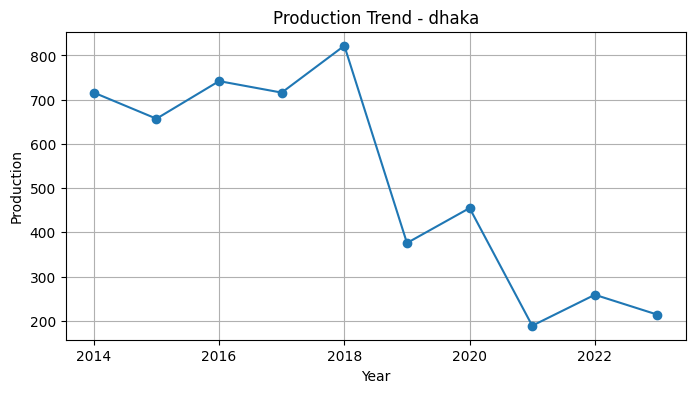

In [4]:
# VISUALIZE TIME SERIES
plt.figure(figsize=(8,4))
plt.plot(ts, marker='o')
plt.title(f"Production Trend - {district_name}")
plt.xlabel("Year")
plt.ylabel("Production")
plt.grid()
plt.show()

ACF → correlation with past values
PACF → direct correlation excluding intermediate lags
“ACF and PACF help determine appropriate AR and MA terms for the SARIMA model.”

<Figure size 1000x400 with 0 Axes>

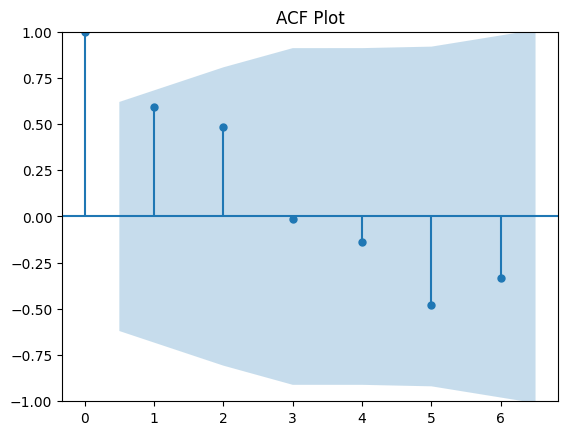

<Figure size 1000x400 with 0 Axes>

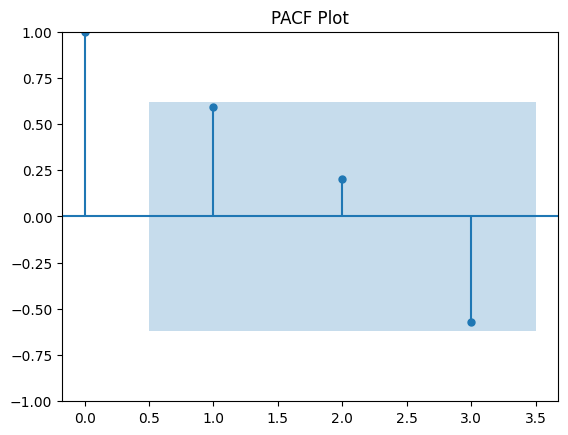

In [5]:
# ACF & PACF
plt.figure(figsize=(10,4))
plot_acf(ts, lags=6)
plt.title("ACF Plot")
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(ts, lags=3)
plt.title("PACF Plot")
plt.show()

“I decomposed the series into trend, seasonality, and residuals to understand underlying structure.”
“The dataset is small and yearly, so I used a minimal period to test decomposition, but in practice this should reflect true seasonal cycles.”

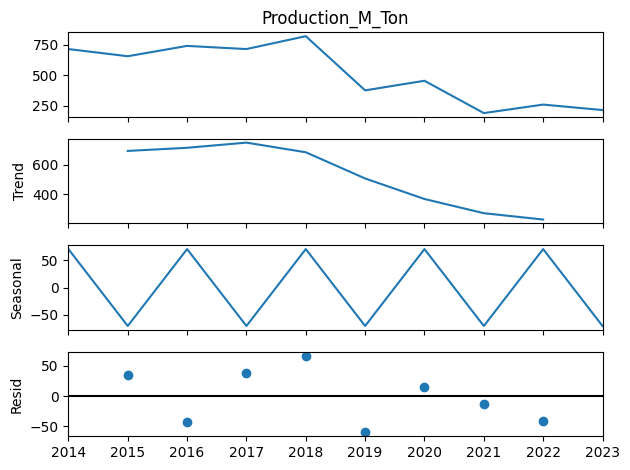

In [6]:
# DECOMPOSITION
decomp = seasonal_decompose(ts, model='additive', period=2)

decomp.plot()
plt.show()

“I used a basic ARIMA(1,1,1) model as a starting baseline since ACF/PACF suggested short memory.”
“No strong seasonal pattern was observed, so I excluded seasonal components.” --> seasonal_order = (0,0,0,0)

In [7]:
# FIT SARIMA
model = SARIMAX(
    ts,
    order=(1,1,1),
    seasonal_order=(0,0,0,0),  # IMPORTANT FIX
    enforce_stationarity=False, # “This relaxes strict stationarity constraints, allowing model flexibility for real-world data.”
    enforce_invertibility=False
)

results = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:       Production_M_Ton   No. Observations:                   10
Model:               SARIMAX(1, 1, 1)   Log Likelihood                 -45.559
Date:                Sat, 11 Apr 2026   AIC                             97.118
Time:                        20:05:44   BIC                             96.955
Sample:                             0   HQIC                            95.112
                                 - 10                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9806      0.225     -4.362      0.000      -1.421      -0.540
ma.L1          1.0000      0.513      1.949      0.051      -0.006       2.006
sigma2      2.135e+04    2.4e-05   8.88e+08      0.0

C:\Users\Nafisa Islam\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nafisa Islam\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [8]:
# FORECAST NEXT YEARS
forecast = results.forecast(steps=3) # "predicted production for the next 3 years using the fitted SARIMA model."

future_years = [ts.index.max() + i for i in range(1, 4)]

forecast_df = pd.DataFrame({
    "Year": future_years,
    "Predicted_Production": forecast
})

forecast_df

C:\Users\Nafisa Islam\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Nafisa Islam\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,Year,Predicted_Production
10,2024,332.202816
11,2025,216.287836
12,2026,329.959262


# APPLY TO ALL 64 DISTRICTS through LOOP

“I generalized the pipeline to automatically train and forecast for all 64 districts.”

In [9]:
all_results = []

for district in df["District"].unique():

    d = df[df["District"] == district].sort_values("Year")
    ts = d.set_index("Year")["Production_M_Ton"]

    if len(ts) < 5:
        continue            # “Time series models need sufficient data points to learn patterns. I skipped districts with insufficient history.”
                            # “Some districts may cause model convergence errors, so I handled failures gracefully.”

    try:
        model = SARIMAX(
            ts,
            order=(1,1,1),
            seasonal_order=(0,0,0,0),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        res = model.fit(disp=False)
        forecast = res.forecast(steps=3)

        last_year = ts.index.max()
        years = [last_year + i for i in range(1, 4)]

        for y, f in zip(years, forecast):
            all_results.append([district, y, f])

    except:
        continue

forecast_df = pd.DataFrame(all_results,
                           columns=["District", "Year", "Predicted_Production"])

C:\Users\Nafisa Islam\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nafisa Islam\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Nafisa Islam\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Nafisa Islam\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported ind

“The final output is a structured dataset of future predictions, which can be used for policy planning or visualization.”

In [10]:
print(forecast_df)

       District  Year  Predicted_Production
0      bagerhat  2024            636.722475
1      bagerhat  2025            595.265466
2      bagerhat  2026            603.785506
3     bandarban  2024              0.000000
4     bandarban  2025              0.000000
..          ...   ...                   ...
187     tangail  2025          12065.033385
188     tangail  2026          12065.082533
189  thakurgaon  2024         169631.916373
190  thakurgaon  2025         169173.353292
191  thakurgaon  2026         169216.050484

[192 rows x 3 columns]


# Interactive HTML choropleth map

“I used GeoPandas for handling geospatial data like shapefiles, and Folium to create an interactive web-based map.”

In [24]:
# Importings 
import geopandas as gpd
import folium

LOAD SHAPEFILE (GeoPandas)
“This shapefile contains district-level boundary data for Bangladesh. Each row represents a district with its geometry (polygon).”

In [11]:
shp_path = "gadm41_BGD_2.shp"
gdf = gpd.read_file(shp_path)

gdf.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
0,BGD.1.1_1,BGD,Bangladesh,BGD.1_1,Barisal,NA,Barguna,NA,NA,Zila,Distict,1004,BD.BA.PR,"MULTIPOLYGON (((89.98476 21.9577, 89.98483 21...."
1,BGD.1.2_1,BGD,Bangladesh,BGD.1_1,Barisal,NA,Barisal,NA,NA,Zila,Distict,1006,BD.BA.PR,"MULTIPOLYGON (((90.43166 22.49055, 90.43195 22..."
2,BGD.1.3_1,BGD,Bangladesh,BGD.1_1,Barisal,NA,Bhola,NA,NA,Zila,Distict,1009,BD.BA.PR,"MULTIPOLYGON (((90.81534 21.88569, 90.81492 21..."
3,BGD.1.4_1,BGD,Bangladesh,BGD.1_1,Barisal,NA,Jhalokati,NA,NA,Zila,Distict,1042,BD.BA.PR,"POLYGON ((90.10083 22.35833, 90.10042 22.35875..."
4,BGD.1.5_1,BGD,Bangladesh,BGD.1_1,Barisal,NA,Patuakhali,NA,NA,Zila,Distict,1078,BD.BA.PR,"MULTIPOLYGON (((90.45658 21.80762, 90.45665 21..."


“I identified the district name column (NAME_2), which is required to join with my prediction dataset.”

In [12]:
gdf.columns

Index(['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2',
       'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2',
       'geometry'],
      dtype='object')

In [13]:
gdf[['NAME_2']].head()

,NAME_2
0,Barguna
1,Barisal
2,Bhola
3,Jhalokati
4,Patuakhali


“Before merging, I standardized district names to lowercase to avoid mismatches due to case sensitivity.”

In [14]:
forecast_df['District'] = forecast_df['District'].str.lower()
gdf['NAME_2'] = gdf['NAME_2'].str.lower()

“Different datasets often use slightly different spellings. I manually corrected known inconsistencies to ensure proper alignment.”

In [18]:
corrections = {
    "bogra": "bogura",
    "brahamanbaria": "brahmanbaria",
    "khagrachhari": "khagrachari",
    "maulvibazar": "moulvibazar",
    "maulavibazar": "moulvibazar",
    "nawabganj": "chapainawabganj"  # standard name
}

gdf["NAME_2"] = gdf["NAME_2"].replace(corrections)
forecast_df["District"] = forecast_df["District"].replace(corrections)

“I checked for unmatched districts to ensure data integrity before merging.”
“This helps detect missing joins and prevents silent data loss.”

In [19]:
set(forecast_df["District"]) - set(gdf["NAME_2"])

set()

In [20]:
print(gdf["NAME_2"].nunique())

64


In [21]:
print(forecast_df["District"].nunique())

64


“Since I want a single-year visualization, I filtered the dataset to 2024 predictions.”

In [22]:
map_df = forecast_df[forecast_df['Year'] == 2024]

“This is a left join where I attach predicted production values to each district geometry. The left join ensures that all districts remain in the map, even if some predictions are missing. Because I don’t want to lose any district boundaries in visualization.”

In [23]:
merged = gdf.merge(
    map_df,
    left_on='NAME_2',
    right_on='District',
    how='left'
)

“I initialized a map centered on Bangladesh with an appropriate zoom level.”

In [ ]:
m = folium.Map(location=[23.7, 90.4], zoom_start=7)

“This creates a choropleth map where district colors represent predicted production values.”
“The color intensity encodes magnitude—darker regions indicate higher production.”

In [25]:
folium.Choropleth(
    geo_data=merged,
    data=merged,
    columns=['NAME_2', 'Predicted_Production'],
    key_on='feature.properties.NAME_2',
    fill_color='YlGnBu',
    fill_opacity=0.8,
    line_opacity=0.3,
    legend_name='Predicted Production (2024)'
).add_to(m)

“I added hover tooltips so users can interactively see district names and predicted values.”

In [26]:
folium.GeoJson(
    merged,
    tooltip=folium.GeoJsonTooltip(
        fields=['NAME_2', 'Predicted_Production'],
        aliases=['District:', 'Predicted Production:'],
        localize=True
    )
).add_to(m)

“The output is a standalone interactive HTML file that can be shared without requiring Python.”

In [27]:
m.save("bangladesh_production_forecast_2024.html")